# 00 — Perfiles de Cluster: Caracterización de Grupos de Riesgo
**Proyecto:** Invarianza de perfiles de deserción PreTec21 ↔ Tec21  
**Equipo 7 · Desarrollo de Aplicaciones Avanzadas de Ciencias Computacionales**

---
Este notebook corre K-Means, describe cada perfil en detalle y exporta
`data/dataset_clustered.csv` para los notebooks de modelos.

> **Nota metodológica:** El Silhouette Score obtenido (~0.17) está por debajo del umbral ideal
> de 0.30. Esto es esperado en datos educativos donde los perfiles de riesgo son continuos
> y se solapan. Los clusters son **interpretables y sustantivamente distintos** pese al bajo
> Silhouette, lo que los hace útiles para el análisis de invarianza.

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from pathlib import Path
from sklearn.cluster      import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics       import silhouette_score, davies_bouldin_score

DATA_DIR = Path('../../data')
IMG_DIR  = Path('../../results/figures/clusters'); IMG_DIR.mkdir(parents=True, exist_ok=True)

SEED      = 42
K         = 4       # clusters — ajustar si se desea explorar otros valores
PRETEC21  = ['AD14','AD15','AD16','AD17','AD18']
TEC21     = ['AD19','AD20']

df = pd.read_csv(DATA_DIR / 'dataset_engineered.csv', low_memory=False)
print(f"✓ dataset_engineered.csv: {df.shape}")
print(f"  PreTec21: {df['generation'].isin(PRETEC21).sum():,}  |  "
      f"Tec21: {df['generation'].isin(TEC21).sum():,}")

✓ dataset_engineered.csv: (77517, 37)
  PreTec21: 53,010  |  Tec21: 24,507


## 1. Selección de variables de clustering y K-Means

Variables de clustering (14):
  PNA
  admission_test_norm
  english.evaluation
  admission.rubric
  apoyo_financiero
  has_extracurriculars
  first_gen_enc
  educ_padres_max
  FTE
  age
  estuvo_prepa_tec
  has_physical
  has_social
  parents_exatec_enc


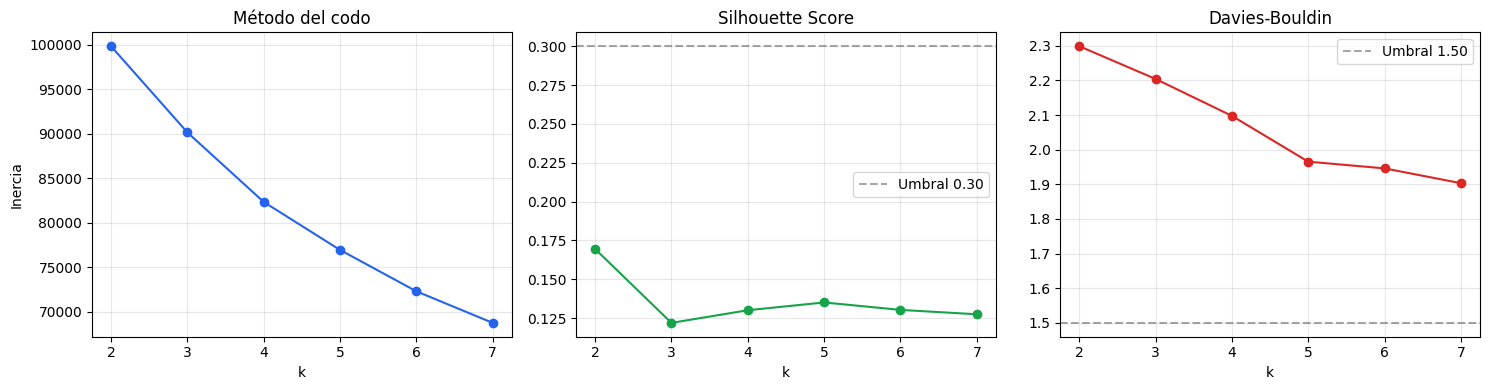


K configurado: 4
Silhouette K=4: 0.130
Davies-Bouldin K=4: 2.098


In [2]:
# Variables de clustering — excluir NSE (cobertura ~0% en PreTec21)
# y variables de fuga (retención, calificaciones post-ingreso)
CLUSTER_COLS = [
    'PNA',                   # rendimiento académico previo
    'admission_test_norm',   # puntaje de admisión normalizado
    'english.evaluation',    # nivel de inglés
    'admission.rubric',      # rubrica de admisión
    'apoyo_financiero',      # beca + préstamo (variable compuesta)
    'has_extracurriculars',  # participación en vida universitaria
    'first_gen_enc',         # primera generación (-1/0/1)
    'educ_padres_max',       # educación máxima de padres
    'FTE',                   # carga académica
    'age',                   # edad de ingreso
    'estuvo_prepa_tec',      # preparatoria TEC (capital social institucional)
    'has_physical',          # actividad física
    'has_social',            # actividad social / liderazgo
    'parents_exatec_enc',    # padres exatec
]
CLUSTER_COLS = [c for c in CLUSTER_COLS if c in df.columns]
print(f"Variables de clustering ({len(CLUSTER_COLS)}):")
for c in CLUSTER_COLS: print(f"  {c}")

df_pre = df[df['generation'].isin(PRETEC21)].copy().reset_index(drop=True)
df_tec = df[df['generation'].isin(TEC21)].copy().reset_index(drop=True)

# Imputar con mediana de PreTec21
medians = df_pre[CLUSTER_COLS].median()
X_pre = df_pre[CLUSTER_COLS].fillna(medians).values.astype(float)
X_tec = df_tec[CLUSTER_COLS].fillna(medians).values.astype(float)

# Escalar con stats de PreTec21
scaler  = StandardScaler()
Xs_pre  = scaler.fit_transform(X_pre)
Xs_tec  = scaler.transform(X_tec)

# Selección de K (submuestra para velocidad)
sample_idx = np.random.RandomState(SEED).choice(len(Xs_pre), min(8000, len(Xs_pre)), replace=False)
Xs_sample  = Xs_pre[sample_idx]

inertias, sils, dbs = [], [], []
K_RANGE = range(2, 8)
for k in K_RANGE:
    km_tmp = KMeans(n_clusters=k, n_init=10, max_iter=200, random_state=SEED)
    lab    = km_tmp.fit_predict(Xs_sample)
    inertias.append(km_tmp.inertia_)
    sils.append(silhouette_score(Xs_sample, lab))
    dbs.append(davies_bouldin_score(Xs_sample, lab))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(K_RANGE, inertias, 'o-', color='#2563eb')
axes[0].set_title('Método del codo'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[0].grid(alpha=0.3)

axes[1].plot(K_RANGE, sils, 'o-', color='#16a34a')
axes[1].axhline(0.30, ls='--', color='gray', alpha=0.7, label='Umbral 0.30')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k'); axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(K_RANGE, dbs, 'o-', color='#dc2626')
axes[2].axhline(1.50, ls='--', color='gray', alpha=0.7, label='Umbral 1.50')
axes[2].set_title('Davies-Bouldin'); axes[2].set_xlabel('k'); axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(IMG_DIR / 'k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nK configurado: {K}")
print(f"Silhouette K={K}: {sils[K-2]:.3f}")
print(f"Davies-Bouldin K={K}: {dbs[K-2]:.3f}")

## 2. Ajuste final y proyección

In [3]:
# Ajustar K-Means en PreTec21
km = KMeans(n_clusters=K, n_init=20, random_state=SEED)
km.fit(Xs_pre)

df_pre = df_pre.copy(); df_pre['cluster'] = km.labels_
df_tec = df_tec.copy(); df_tec['cluster'] = km.predict(Xs_tec)

# Métricas finales
sil_pre = silhouette_score(Xs_pre, km.labels_)
db_pre  = davies_bouldin_score(Xs_pre, km.labels_)
sil_tec = silhouette_score(Xs_tec, df_tec['cluster'].values)
db_tec  = davies_bouldin_score(Xs_tec, df_tec['cluster'].values)

print("═══ Métricas de clustering ═══")
print(f"{'':20} {'PreTec21':>10} {'Tec21':>10} {'Umbral':>10}")
print(f"{'Silhouette':20} {sil_pre:>10.3f} {sil_tec:>10.3f} {'>= 0.30':>10}")
print(f"{'Davies-Bouldin':20} {db_pre:>10.3f} {db_tec:>10.3f} {'<= 1.50':>10}")

print("\n⚠ Nota: Los scores por debajo del umbral reflejan la naturaleza continua")
print("  de los perfiles de riesgo en datos educativos. Los clusters son")
print("  sustantivamente interpretables aunque no estén bien separados geométricamente.")

# Ordenar clusters por tasa de deserción (0=menor riesgo, mayor=mayor riesgo)
dropout_order = (df_pre.groupby('cluster')['retention']
                 .apply(lambda x: (x==0).mean())
                 .sort_values().index.tolist())
remap = {old: new for new, old in enumerate(dropout_order)}
df_pre['cluster'] = df_pre['cluster'].map(remap)
df_tec['cluster'] = df_tec['cluster'].map(remap)

print("\n✓ Clusters reordenados: 0=menor deserción → último=mayor deserción")
for k in range(K):
    sub = df_pre[df_pre['cluster']==k]
    rate = (sub['retention']==0).mean()*100
    print(f"  Cluster {k}: {rate:.1f}% deserción  n={len(sub):,}")

═══ Métricas de clustering ═══
                       PreTec21      Tec21     Umbral
Silhouette                0.131      0.091    >= 0.30
Davies-Bouldin            2.106      1.946    <= 1.50

⚠ Nota: Los scores por debajo del umbral reflejan la naturaleza continua
  de los perfiles de riesgo en datos educativos. Los clusters son
  sustantivamente interpretables aunque no estén bien separados geométricamente.

✓ Clusters reordenados: 0=menor deserción → último=mayor deserción
  Cluster 0: 5.7% deserción  n=20,109
  Cluster 1: 7.1% deserción  n=9,617
  Cluster 2: 10.9% deserción  n=2,643
  Cluster 3: 12.5% deserción  n=20,641


## 3. Descripción de perfiles

In [4]:
COLORS = ['#16a34a','#2563eb','#f59e0b','#dc2626','#7c3aed','#0891b2']

# Nombres interpretativos (basados en las variables diferenciadoras)
CLUSTER_NAMES = {
    0: "Perfil A — Bajo Riesgo: Academicamente sólido, con apoyo",
    1: "Perfil B — Riesgo Moderado: Integrado sin apoyo financiero",
    2: "Perfil C — Riesgo Moderado-Alto: Primera generación o desvinculado",
    3: "Perfil D — Alto Riesgo: Desvinculado, bajo rendimiento relativo",
}

# Estadísticos por cluster
PROFILE_VARS = {
    'Rendimiento académico': ['PNA','admission_test_norm','english.evaluation','admission.rubric'],
    'Financiero / institucional': ['apoyo_financiero','FTE','estuvo_prepa_tec','parents_exatec_enc'],
    'Integración': ['has_extracurriculars','has_physical','has_social'],
    'Socioeconómico / familiar': ['first_gen_enc','educ_padres_max'],
    'Demográfico': ['age','is_male'],
}

print("═"*70)
print("PERFILES DE CLUSTER — PreTec21 (AD14–AD18)")
print("═"*70)

all_stats = []
for k in range(K):
    sub = df_pre[df_pre['cluster']==k]
    dropout = (sub['retention']==0).mean()*100
    print(f"\n{'─'*70}")
    print(f"CLUSTER {k}  |  {CLUSTER_NAMES.get(k, f'Cluster {k}')}")
    print(f"  n = {len(sub):,}  ({len(sub)/len(df_pre)*100:.1f}% del total PreTec21)")
    print(f"  Tasa de deserción: {dropout:.1f}%")
    print()
    for section, vars_ in PROFILE_VARS.items():
        v_present = [v for v in vars_ if v in sub.columns]
        if not v_present: continue
        print(f"  [{section}]")
        for v in v_present:
            mean_val  = sub[v].mean()
            global_m  = df_pre[v].mean()
            diff      = mean_val - global_m
            arrow = "↑" if diff > 0.05*abs(global_m+1e-6) else ("↓" if diff < -0.05*abs(global_m+1e-6) else "→")
            print(f"    {v:<35} {mean_val:>7.3f}  {arrow} (global={global_m:.3f})")
    all_stats.append({'cluster': k, 'n': len(sub), 'dropout_pct': dropout,
                      **{v: sub[v].mean() for v in CLUSTER_COLS if v in sub.columns}})

stats_df = pd.DataFrame(all_stats)
print(f"\n{'─'*70}")
print("\n→ Tabla resumen exportada en stats_df")

══════════════════════════════════════════════════════════════════════
PERFILES DE CLUSTER — PreTec21 (AD14–AD18)
══════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
CLUSTER 0  |  Perfil A — Bajo Riesgo: Academicamente sólido, con apoyo
  n = 20,109  (37.9% del total PreTec21)
  Tasa de deserción: 5.7%

  [Rendimiento académico]
    PNA                                  90.969  → (global=87.352)
    admission_test_norm                   0.845  ↑ (global=0.803)
    english.evaluation                    5.653  ↑ (global=5.194)
    admission.rubric                     35.724  ↑ (global=33.314)
  [Financiero / institucional]
    apoyo_financiero                      0.374  ↑ (global=0.236)
    FTE                                   1.111  → (global=1.074)
    estuvo_prepa_tec                      0.569  ↑ (global=0.480)
    parents_exatec_enc                    0.130  ↑ (global=0.114)
  [Integración]
 

## 4. Visualizaciones de perfiles

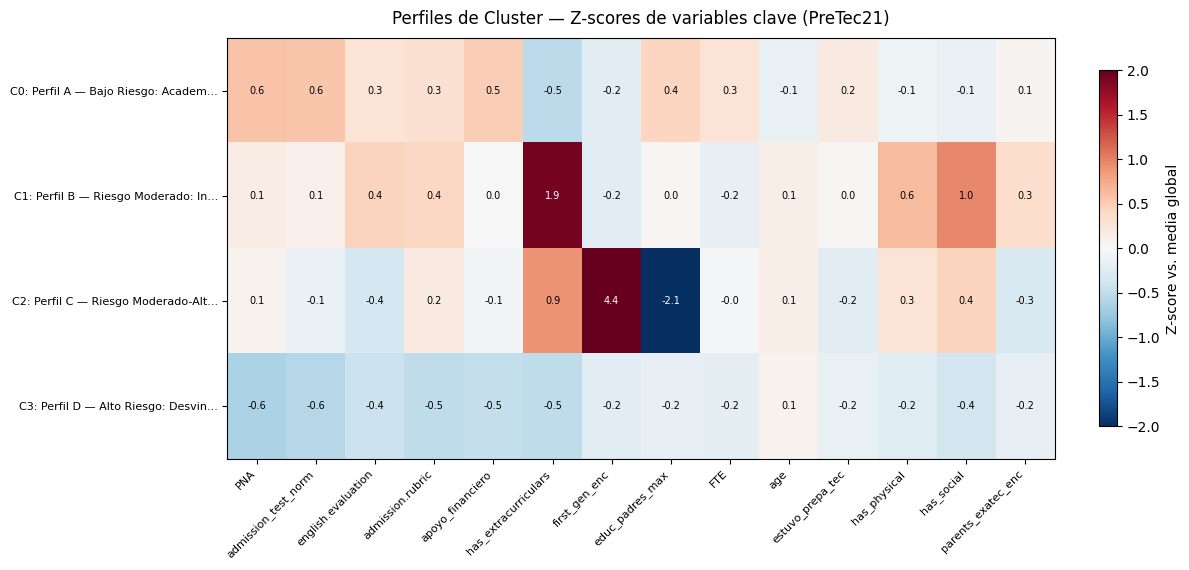

In [5]:
# Heatmap de z-scores por cluster
grand_mean = df_pre[CLUSTER_COLS].mean()
grand_std  = df_pre[CLUSTER_COLS].std().replace(0, 1)

z_mat = np.zeros((K, len(CLUSTER_COLS)))
for k in range(K):
    sub  = df_pre[df_pre['cluster']==k]
    z_mat[k] = (sub[CLUSTER_COLS].mean() - grand_mean) / grand_std

fig, ax = plt.subplots(figsize=(max(12, len(CLUSTER_COLS)*0.7), K*1.2+1))
im = ax.imshow(z_mat, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks(range(len(CLUSTER_COLS)))
ax.set_xticklabels(CLUSTER_COLS, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(K))
ax.set_yticklabels([f"C{k}: {CLUSTER_NAMES.get(k,k)[:30]}..." for k in range(K)], fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.02, label='Z-score vs. media global')
ax.set_title('Perfiles de Cluster — Z-scores de variables clave (PreTec21)', pad=10)

# Añadir valores en celdas
for i in range(K):
    for j in range(len(CLUSTER_COLS)):
        ax.text(j, i, f'{z_mat[i,j]:.1f}', ha='center', va='center', fontsize=7,
                color='white' if abs(z_mat[i,j]) > 1 else 'black')

plt.tight_layout()
plt.savefig(IMG_DIR / 'cluster_heatmap_pretec21.png', dpi=150, bbox_inches='tight')
plt.show()

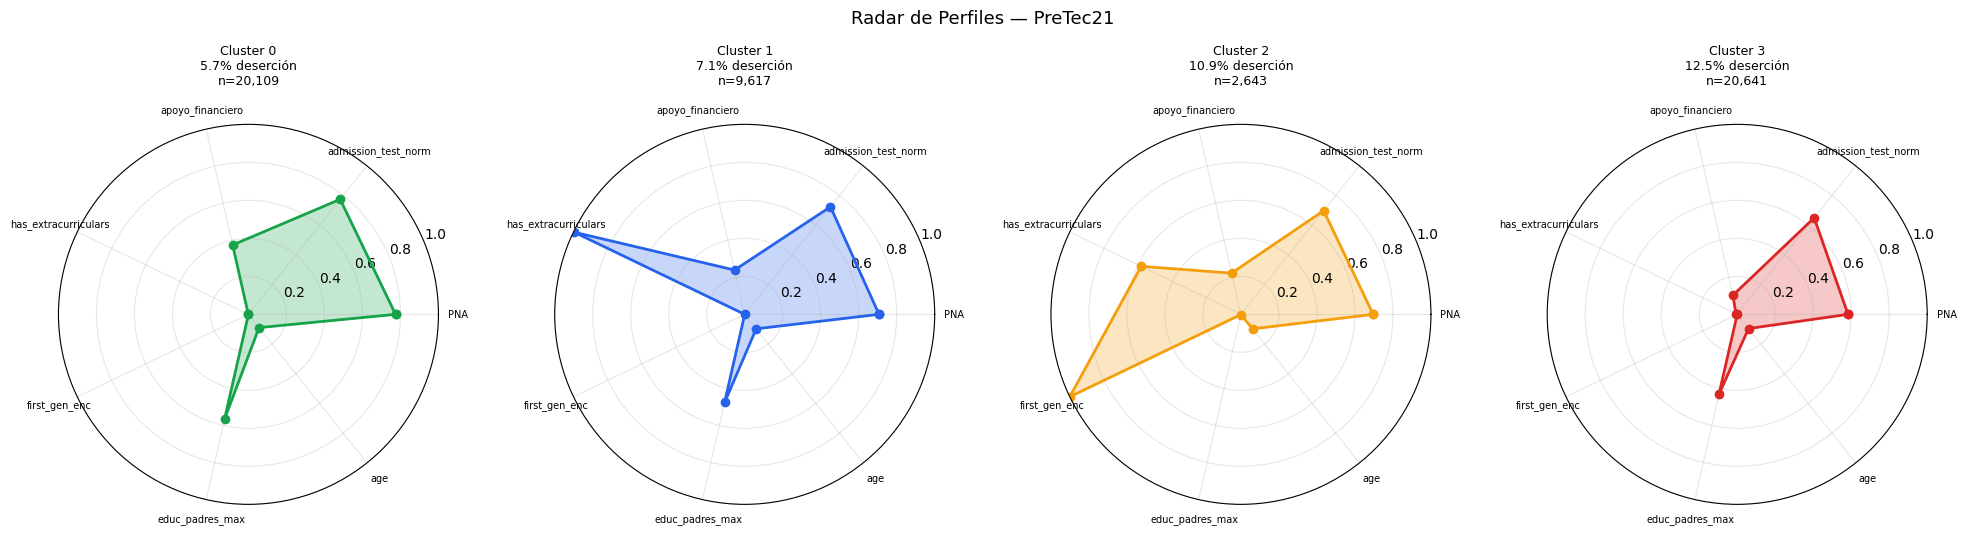

In [6]:
# Radar chart por cluster (top variables)
TOP_RADAR = ['PNA','admission_test_norm','apoyo_financiero',
             'has_extracurriculars','first_gen_enc','educ_padres_max','age']
TOP_RADAR = [v for v in TOP_RADAR if v in df_pre.columns]

angles = np.linspace(0, 2*np.pi, len(TOP_RADAR), endpoint=False).tolist()
angles += angles[:1]  # cerrar el polígono

fig, axes = plt.subplots(1, K, figsize=(5*K, 5), subplot_kw=dict(polar=True))
if K == 1: axes = [axes]

for k, ax in enumerate(axes):
    sub    = df_pre[df_pre['cluster']==k]
    values = [(sub[v].mean() - df_pre[v].min()) /
              (df_pre[v].max() - df_pre[v].min() + 1e-9) for v in TOP_RADAR]
    values += values[:1]
    ax.plot(angles, values, 'o-', lw=2, color=COLORS[k])
    ax.fill(angles, values, alpha=0.25, color=COLORS[k])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(TOP_RADAR, size=7)
    ax.set_ylim(0, 1)
    ax.set_title(f"Cluster {k}\n{(sub['retention']==0).mean()*100:.1f}% deserción\nn={len(sub):,}",
                 size=9, pad=15)
    ax.grid(alpha=0.3)

plt.suptitle('Radar de Perfiles — PreTec21', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / 'cluster_radar_pretec21.png', dpi=150, bbox_inches='tight')
plt.show()

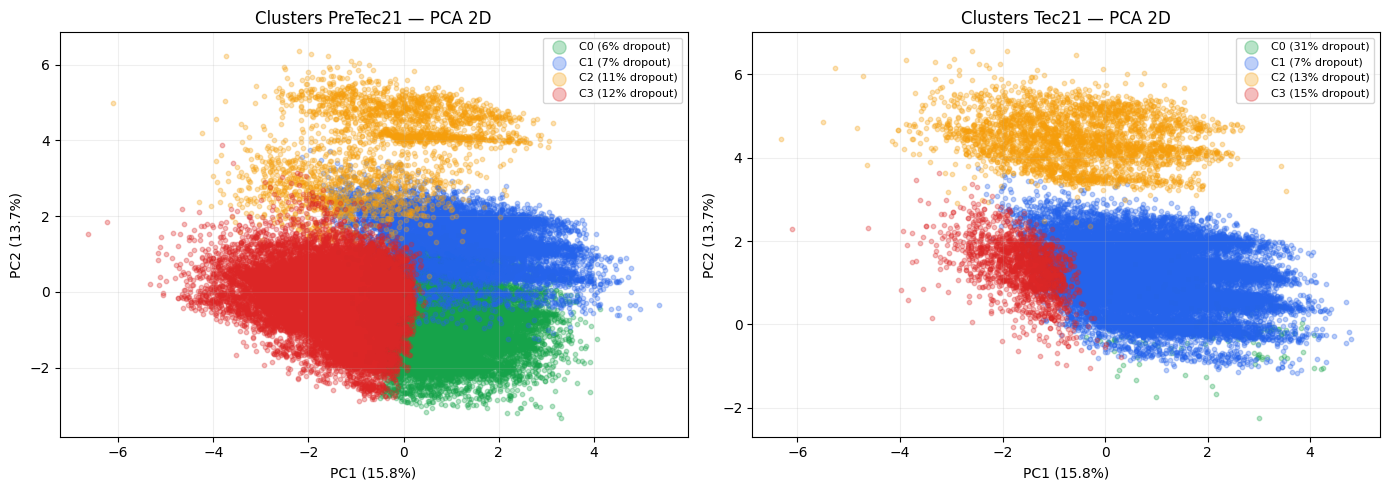

In [7]:
# PCA 2D — visualización de separación
pca = PCA(n_components=2, random_state=SEED) if 'PCA' in dir() else None
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=SEED)
pca.fit(Xs_pre)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, Xs_r, df_r) in zip(axes, [
    ('PreTec21', Xs_pre, df_pre),
    ('Tec21',    Xs_tec, df_tec)
]):
    Z = pca.transform(Xs_r)
    for k in range(K):
        mask = df_r['cluster'] == k
        dropout = (df_r.loc[mask, 'retention']==0).mean()*100
        ax.scatter(Z[mask.values, 0], Z[mask.values, 1],
                   s=10, alpha=0.3, color=COLORS[k],
                   label=f'C{k} ({dropout:.0f}% dropout)')
    ax.set_title(f'Clusters {name} — PCA 2D')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(markerscale=3, fontsize=8); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(IMG_DIR / 'cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()

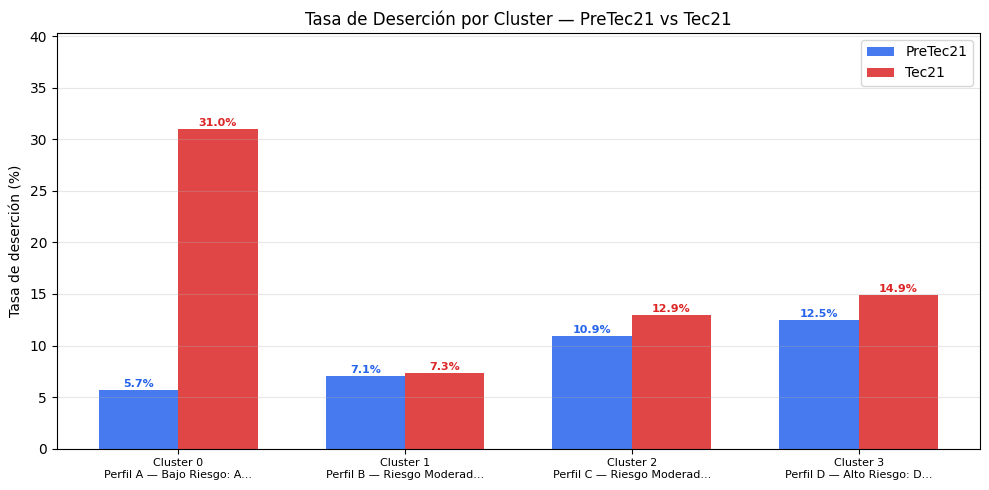

Análisis de invarianza en ordenamiento de clusters:
  Orden PreTec21 (menor→mayor deserción): [0, 1, 2, 3]
  Orden Tec21    (menor→mayor deserción): [1, 2, 3, 0]
  ⚠ Ordenamiento cambia entre regímenes


In [8]:
# Tasa de deserción por cluster × régimen (comparación de invarianza)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(K); w = 0.35

rates_pre = [(df_pre[df_pre['cluster']==k]['retention']==0).mean()*100 for k in range(K)]
rates_tec = [(df_tec[df_tec['cluster']==k]['retention']==0).mean()*100 for k in range(K)]

ax.bar(x - w/2, rates_pre, w, label='PreTec21', color='#2563eb', alpha=0.85)
ax.bar(x + w/2, rates_tec, w, label='Tec21',    color='#dc2626', alpha=0.85)

for i, (rp, rt) in enumerate(zip(rates_pre, rates_tec)):
    ax.text(i-w/2, rp+0.3, f'{rp:.1f}%', ha='center', fontsize=8, color='#2563eb', fontweight='bold')
    ax.text(i+w/2, rt+0.3, f'{rt:.1f}%', ha='center', fontsize=8, color='#dc2626', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {k}\n{CLUSTER_NAMES.get(k,k)[:25]}...' for k in range(K)],
                   fontsize=8)
ax.set_ylabel('Tasa de deserción (%)'); ax.set_ylim(0, max(rates_pre+rates_tec)*1.3)
ax.set_title('Tasa de Deserción por Cluster — PreTec21 vs Tec21')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / 'cluster_dropout_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Análisis de invarianza en ordenamiento de clusters:")
rank_pre = np.argsort(rates_pre)
rank_tec = np.argsort(rates_tec)
print(f"  Orden PreTec21 (menor→mayor deserción): {rank_pre.tolist()}")
print(f"  Orden Tec21    (menor→mayor deserción): {rank_tec.tolist()}")
order_preserved = list(rank_pre) == list(rank_tec)
print(f"  {'✓ Ordenamiento preservado' if order_preserved else '⚠ Ordenamiento cambia entre regímenes'}")

## 5. Exportar dataset con asignación de clusters

In [9]:
df_full = pd.concat([df_pre, df_tec], ignore_index=True)

# Añadir nombre descriptivo del cluster
df_full['cluster_name'] = df_full['cluster'].map(
    {k: f"C{k}: {v.split('—')[1].strip()}" for k, v in CLUSTER_NAMES.items()}
)

output_path = DATA_DIR / 'dataset_clustered.csv'
df_full.to_csv(output_path, index=False)

print(f"✓ dataset_clustered.csv guardado: {df_full.shape}")
print(f"\nDistribución de clusters:")
for regime, gens in [('PreTec21', ['AD14','AD15','AD16','AD17','AD18']),
                      ('Tec21',    ['AD19','AD20'])]:
    sub = df_full[df_full['generation'].isin(gens)]
    print(f"\n  {regime}  (n={len(sub):,})")
    for k in range(K):
        sk = sub[sub['cluster']==k]
        rate = (sk['retention']==0).mean()*100
        print(f"    Cluster {k}: n={len(sk):>5,}  dropout={rate:.1f}%  "
              f"{CLUSTER_NAMES.get(k,k)[:40]}")

✓ dataset_clustered.csv guardado: (77517, 39)

Distribución de clusters:

  PreTec21  (n=53,010)
    Cluster 0: n=20,109  dropout=5.7%  Perfil A — Bajo Riesgo: Academicamente s
    Cluster 1: n=9,617  dropout=7.1%  Perfil B — Riesgo Moderado: Integrado si
    Cluster 2: n=2,643  dropout=10.9%  Perfil C — Riesgo Moderado-Alto: Primera
    Cluster 3: n=20,641  dropout=12.5%  Perfil D — Alto Riesgo: Desvinculado, ba

  Tec21  (n=24,507)
    Cluster 0: n=  129  dropout=31.0%  Perfil A — Bajo Riesgo: Academicamente s
    Cluster 1: n=19,488  dropout=7.3%  Perfil B — Riesgo Moderado: Integrado si
    Cluster 2: n=3,129  dropout=12.9%  Perfil C — Riesgo Moderado-Alto: Primera
    Cluster 3: n=1,761  dropout=14.9%  Perfil D — Alto Riesgo: Desvinculado, ba
